In [6]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pandas.tseries.offsets import DateOffset
import gsw

In [7]:
### CMA
ds = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/All/new_all_CORA_MEOP_ARGO_2024.nc")
ds = ds.rename({"LATITUDE":"latitude", "LONGITUDE":"longitude"})

In [8]:
end_date = pd.to_datetime("2023-12-31")

df = ds.mld.to_dataframe().reset_index() 

def make_ds_cut(df, nb_bins=39, start_date = None, end_date = end_date, freq="M"):
    # detect coordinate column names
    lon_col = "longitude"
    lat_col = "latitude"
    time_col = "time"

    bins_dt = pd.date_range(
        start=start_date if start_date is not None else df[time_col].min() + DateOffset(months=-1),
        end= end_date + DateOffset(months=+1),
        freq=freq
    )

    cut_lat_label = pd.cut(df[lat_col], nb_bins)
    cut_lon_label = pd.cut(df[lon_col], nb_bins)
    cut_time_label = pd.cut(df[time_col], bins=bins_dt)

    df_cut_label = df.drop([lat_col, lon_col, time_col], axis=1)
    df_cut_label = df_cut_label.groupby([cut_time_label, cut_lon_label, cut_lat_label]).mean()

    lat_mid = pd.IntervalIndex(df_cut_label.index.get_level_values(2)).mid.unique()
    lon_mid = pd.IntervalIndex(df_cut_label.index.get_level_values(1)).mid.unique()
    time_mid = pd.IntervalIndex(df_cut_label.index.get_level_values(0)).mid.unique()

    df_cut_label.index = df_cut_label.index.set_levels(time_mid.values, level=0)
    df_cut_label.index = df_cut_label.index.set_levels(lon_mid, level=1)
    df_cut_label.index = df_cut_label.index.set_levels(lat_mid.values, level=2)

    df_cut = df_cut_label.copy()
    df_cut.replace(0, np.nan, inplace=True)

    ds_cut = df_cut.to_xarray()
    ds_cut["latitude"] = sorted(lat_mid)
    ds_cut["longitude"] = sorted(lon_mid)
    ds_cut["time"] = time_mid

    ds_cut = ds_cut.drop("uid")
    df_cut = df_cut.drop(columns=["uid"])

    return ds_cut, df_cut

ds, df = make_ds_cut(df, nb_bins=39)

/tmp/ipykernel_2206809/767122001.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bins_dt = pd.date_range(
/tmp/ipykernel_2206809/767122001.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cut_label = df_cut_label.groupby([cut_time_label, cut_lon_label, cut_lat_label]).mean()
/tmp/ipykernel_2206809/767122001.py:40: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_cut = ds_cut.drop("uid")


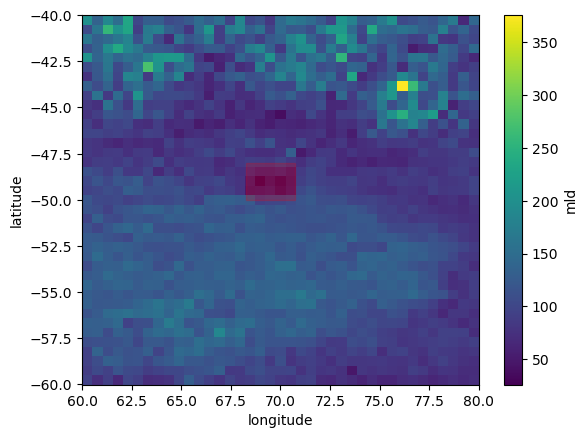

In [9]:
### We want to highlight the pixels corresponding to Kerguelen
lon_min = 68.25
lon_max = 70.75
lat_min = -50
lat_max = -48

mask = (
	(ds.longitude >= lon_min) & (ds.longitude <= lon_max)
	& (ds.latitude >= lat_min) & (ds.latitude <= lat_max)
)

ds.mean("time").mld.plot(x="longitude")
ax = plt.gca()

rect = plt.Rectangle(
	(lon_min, lat_min),
	lon_max - lon_min,
	lat_max - lat_min,
	facecolor="red",
	edgecolor="red",
	alpha=0.2,
	linewidth=1,
)
ax.add_patch(rect)

### When satisfied by the region, we mask it in the dataset
ds_masked = ds.where(~mask)

In [10]:
ds = ds_masked.copy()
ds_clim = ds.groupby("time.month").mean("time").mean(["latitude", "longitude"])
ds_anom = ds.groupby("time.month") - ds_clim

ds_anom = ds_anom.where(~mask, other=0)
ds_clim = ds_clim.where(~mask, other=0)
ds_anom.to_netcdf("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/CMA_anom.nc")
ds_clim.to_netcdf("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/CMA_clim.nc")

In [8]:
### Now that we removed the seasonal cycle we mask kerguelen with 0 instead of nan for the R analysis
# ds = ds_anom.where(~mask, other=0) 
# ds_clim = ds_clim.where(~mask, other=0)
# ds.to_netcdf("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/CMA_anom.nc")
# ds_clim.to_netcdf("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/CMA_clim.nc")
df = ds.to_dataframe().reset_index()
### We modify the dataset for the R analysis 
df['year'] = df.time.dt.year
df["mth"] = df.time.dt.month
df = df.drop(columns="time")
df = df.rename(columns={"latitude" : "lat","longitude" : "long"})
df = df.fillna("NA")
df = df[["long","lat","mth","year","mld"]]
df = df.sort_values(["year","mth","long","lat"])
df = df.reset_index(drop=True)

In [ ]:
### Number of bins for each month = nb_lat_one_month * nb_long_one_month 
nb_lat_one_month=len(np.unique(df.lat))
nb_long_one_month=len(np.unique(df.long))
nb_bins_one_month = nb_lat_one_month * nb_long_one_month
switch = nb_long_one_month*nb_lat_one_month
switch
df_append = df[:switch].copy()
new_df = df.copy()
new_df

,long,lat,mth,year,mld
0,60.2465,-59.7525,1,2007,NA
1,60.2465,-59.2300,1,2007,NA
2,60.2465,-58.7175,1,2007,NA
3,60.2465,-58.2045,1,2007,NA
4,60.2465,-57.6915,1,2007,NA
...,...,...,...,...,...
310279,79.7435,-42.3080,12,2023,NA
310280,79.7435,-41.7955,12,2023,NA
310281,79.7435,-41.2825,12,2023,NA
310282,79.7435,-40.7695,12,2023,NA


In [9]:
df.to_csv("/home/jupyter-vincent2/vincent/process_profiles/data/R_analysis_2026/raw/CMA_masked.txt",sep=" ",index=False)
ds.to_netcdf("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/CMA_gridded.nc")